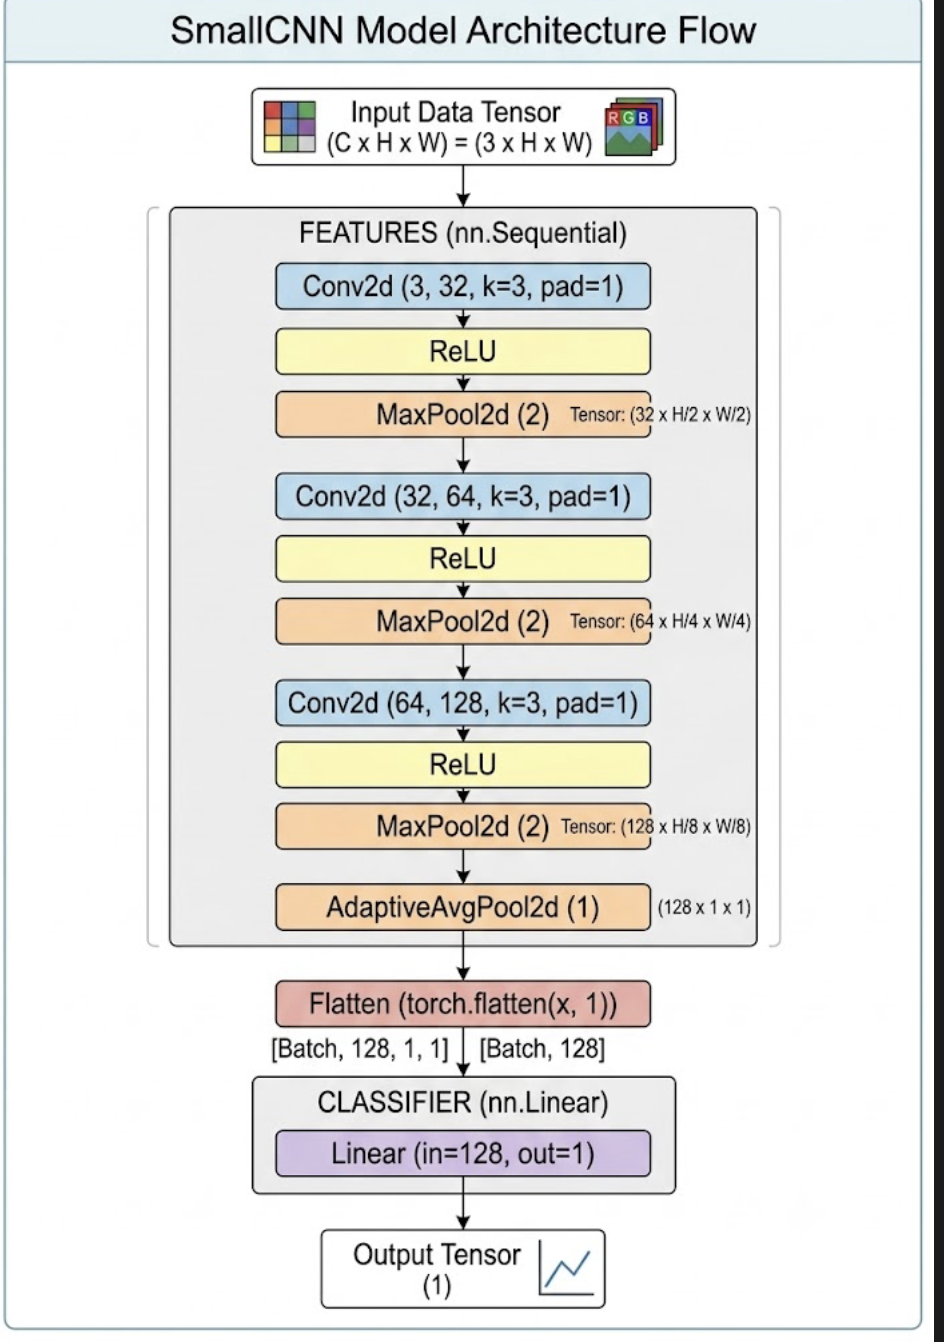

## IMPORTS

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.optim import AdamW
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import  ToTensor, Compose
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from ptflops import get_model_complexity_info

## Data Transformation and dataset split and Loading

In [5]:
mean=[0.4887, 0.4554, 0.4172]
std_dev=[0.2601, 0.2533, 0.2560]

In [6]:
custom_transform= transforms.Compose([
    transforms.Resize((224,224)),# resizes the image to 224 px x 224 px
    transforms.ToTensor(),   # converts the PIL image to Tensor
    transforms.Normalize(mean,std_dev)
])

In [7]:
transforms.Normalize(mean,std_dev)

Normalize(mean=[0.4887, 0.4554, 0.4172], std=[0.2601, 0.2533, 0.256])

In [8]:
dataset= ImageFolder(root="/kaggle/input/datasets/parth04pt/cat-dog-images/data", transform=custom_transform)

In [9]:
gen = torch.Generator().manual_seed(42)

In [10]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size

train_dataset, test_dataset= random_split(dataset, [train_size, test_size], generator=gen)

In [11]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False , num_workers=2, pin_memory=True)

In [12]:
device = torch.device('cuda')

## Class

In [13]:
class SmallCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)

        )

        self.classifier = nn.Linear(128,1)

    def forward(self,x):

        x = self.features(x)

        x = torch.flatten(x,1)

        x = self.classifier(x)

        return x

## Model Object, loss, optim, schedular

In [14]:
model= SmallCNN().to(device)

In [15]:
epochs=20

In [16]:
loss=nn.BCEWithLogitsLoss()
optim= AdamW(model.parameters(),lr=3e-4,weight_decay=1e-4)
schedular=CosineAnnealingLR(optim,T_max=epochs)

# TRAINING LOOP

In [17]:
start = time()

for epoch in tqdm(range(epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()
    schedular.step()
    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

  0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  5%|▌         | 1/20 [01:13<23:15, 73.46s/it]

Loss Epoch 1: 0.6567
Accuracy Epoch 1: 59.42%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 10%|█         | 2/20 [02:05<18:17, 60.96s/it]

Loss Epoch 2: 0.6342
Accuracy Epoch 2: 62.86%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 15%|█▌        | 3/20 [02:57<16:05, 56.82s/it]

...

Loss Epoch 18: 0.5284
Accuracy Epoch 18: 74.16%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 95%|█████████▌| 19/20 [16:50<00:52, 52.05s/it]

Loss Epoch 19: 0.5274
Accuracy Epoch 19: 74.15%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 20/20 [17:42<00:00, 53.13s/it]

Loss Epoch 20: 0.5269
Accuracy Epoch 20: 74.15%


# TESTING LOOP

In [18]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

Test Loss : 0.5449
Test Accuracy : 72.56%
Test Time : 20.00s


## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [28]:
from PIL import Image
model.eval()
dog = Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/dog.jpeg").convert("RGB")
cat=Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/cat.png").convert("RGB")


In [29]:
cat_tensor = custom_transform(cat)
dog_tensor = custom_transform(dog)

In [30]:
start= time()
logit1 = model(dog_tensor.unsqueeze(0).to(device))
prob1 = torch.sigmoid(logit1)
prediction1 = int(prob1 > 0.5)
infer_time1 = time()- start

In [31]:
confidence1 = prob1.item()

In [32]:
cls=["cat", "dog"]

In [33]:
mean=torch.tensor(mean)
std_dev=torch.tensor(std_dev)

/tmp/ipykernel_58/1328199040.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean=torch.tensor(mean)
/tmp/ipykernel_58/1328199040.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_dev=torch.tensor(std_dev)


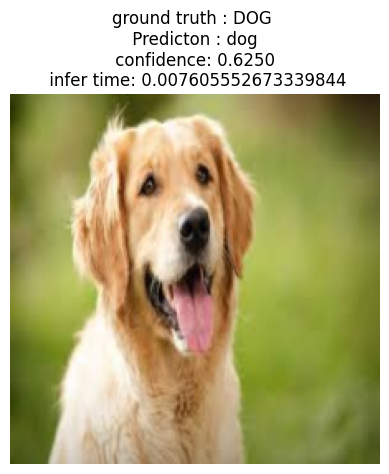

In [34]:
plt.title(f"ground truth : DOG \n Predicton : {cls[prediction1]} \n confidence: {confidence1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [35]:
start= time()
logit2 = model(cat_tensor.unsqueeze(0).to(device))
prob2 = torch.sigmoid(logit2)
prediction2 = int(prob2 > 0.5)
infer_time2 = time()- start

In [36]:
confidence2 = 1-prob2.item()

In [37]:
prob2

tensor([[0.3728]], device='cuda:0', grad_fn=<SigmoidBackward0>)

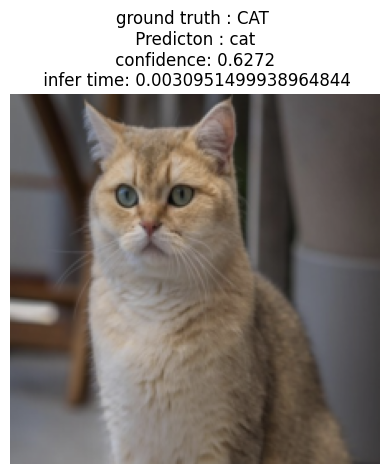

In [38]:
plt.title(f"ground truth : CAT \n Predicton : {cls[prediction2]} \n confidence: {confidence2:.4f} \n infer time: {infer_time2}")
img= cat_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [40]:
num_paramerters=0
num_layers=0
for p in model.parameters():
    num_layers+=1
    num_paramerters+=p.numel()
    #weights
    #bias

In [41]:
memory_usage= torch.cuda.memory_allocated()/1024**2

In [42]:
macs, params = get_model_complexity_info(model,(3,224,224),as_strings=False,print_per_layer_stat=False)

In [43]:
flops= macs*2

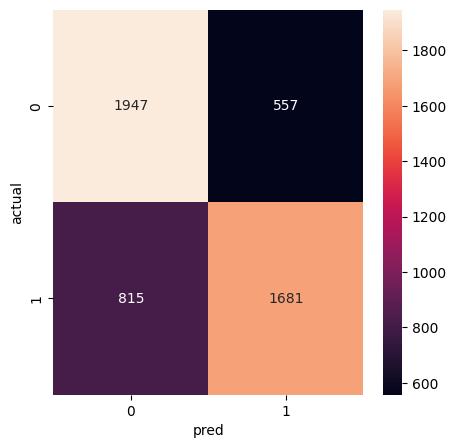

In [44]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [47]:
print("="*60)
print("SMALL CNN EVALUATION RESULTS")
print("="*60)

print(f"Model         : SmallCNN")
print(f"Epochs        : {epochs}")

print()

print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {pre[0]:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")

print()

print(f"Training Time : {train_time:.2f}s")
print(f"Testing Time  : {test_time:.2f}s")

print()

print(f"Parameters    : {num_paramerters:,}")
print(f"FLOPs         : {flops:,.0f}")
print(f"Layers        : {num_layers}")
print(f"Memory Usage  : {memory_usage:.2f} MB")

print()

print("Classes       :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

SMALL CNN EVALUATION RESULTS
Model         : SmallCNN
Epochs        : 20

Accuracy      : 0.7256
Precision     : 0.7511
Recall        : 0.6735
F1 Score      : 0.7102

Training Time : 1062.65s
Testing Time  : 20.00s

Parameters    : 93,377
FLOPs         : 1,040,048,386
Layers        : 8
Memory Usage  : 60.77 MB

Classes       : ['cat', 'dog']

Confusion Matrix
[[1947  557]
 [ 815 1681]]


In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       0.70      0.78      0.74      2504
         dog       0.75      0.67      0.71      2496

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.72      5000
weighted avg       0.73      0.73      0.72      5000

